In [1]:
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [2]:
network_list = [
    'conf','email_eu','hospital','school','work'
]

In [3]:
network_name = network_list[1]
complex_c = pd.read_csv(f'../results/unweighted/given_th/unweighted_complex_{network_name}_EPH.csv')
simple_c = pd.read_csv(f'../results/unweighted/given_th/unweighted_simple_{network_name}_EPH.csv')

In [4]:
for th in complex_c['theta'].unique():
    complex_curr = complex_c[complex_c['theta'] == th]
    complex_curr = complex_curr[['EPH','corr']]
    simple_curr = simple_c[['EPH','corr']]

In [5]:
th=2
complex_curr = complex_c[complex_c['theta'] == th]
complex_curr = complex_curr[['EPH','corr']]
complex_curr['complex'] = 1
simple_curr = simple_c[['EPH','corr']]
simple_curr['complex'] = 0

merged = pd.concat([simple_curr,complex_curr])
merged = merged.sample(len(merged),random_state=1)

X_tda = merged['EPH']
X_prl = merged['corr']
y = merged['complex']



<ipython-input-5-28cd4bcf3d76>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from scipy import stats


# 1. Split the data into train and test sets for both features
X_tda_train, X_tda_test, y_tda_train, y_tda_test = train_test_split(X_tda, y, test_size=0.5, random_state=42)
X_prl_train, X_prl_test, y_prl_train, y_prl_test = train_test_split(X_prl, y, test_size=0.5, random_state=42)
# 2. Create and train decision tree classifiers for both features
dt_tda = DecisionTreeClassifier(random_state=42)
dt_prl = DecisionTreeClassifier(random_state=42)
# dt_tda = RandomForestClassifier(random_state=42)
# dt_prl = RandomForestClassifier(random_state=42)

dt_tda.fit(X_tda_train.values.reshape(-1, 1), y_tda_train)
dt_prl.fit(X_prl_train.values.reshape(-1, 1), y_prl_train)

# Make predictions on test sets
y_tda_pred = dt_tda.predict(X_tda_test.values.reshape(-1, 1))
y_prl_pred = dt_prl.predict(X_prl_test.values.reshape(-1, 1))

# Calculate accuracies
accuracy_tda = accuracy_score(y_tda_test, y_tda_pred)
accuracy_prl = accuracy_score(y_prl_test, y_prl_pred)

# 3. Calculate 95% confidence intervals for both accuracies
def confidence_interval(accuracy, n, confidence=0.95):
    std_error = np.sqrt(accuracy * (1 - accuracy) / n)
    z_score = stats.norm.ppf((1 + confidence) / 2)
    margin_of_error = z_score * std_error
    return (accuracy - margin_of_error, accuracy + margin_of_error)

n_tda = len(y_tda_test)
n_prl = len(y_prl_test)

ci_tda = confidence_interval(accuracy_tda, n_tda)
ci_prl = confidence_interval(accuracy_prl, n_prl)

# Print results
print(f"EPH (TDA) Decision Tree Accuracy: {accuracy_tda:.4f}")
print(f"EPH (TDA) 95% Confidence Interval: ({ci_tda[0]:.4f}, {ci_tda[1]:.4f})")
print(f"Correlation (PRL) Decision Tree Accuracy: {accuracy_prl:.4f}")
print(f"Correlation (PRL) 95% Confidence Interval: ({ci_prl[0]:.4f}, {ci_prl[1]:.4f})")

EPH (TDA) Decision Tree Accuracy: 0.7060
EPH (TDA) 95% Confidence Interval: (0.6661, 0.7459)
Correlation (PRL) Decision Tree Accuracy: 0.5540
Correlation (PRL) 95% Confidence Interval: (0.5104, 0.5976)


<ipython-input-7-76c3d2d0ea91>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-7-76c3d2d0ea91>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-7-76c3d2d0ea91>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retu

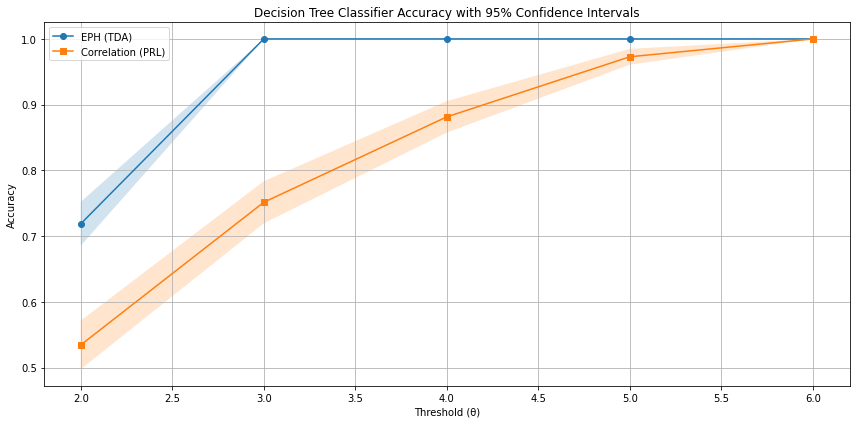


Threshold θ = 2
EPH (TDA) Accuracy: 0.7186, CI: (0.6853, 0.7519)
Correlation (PRL) Accuracy: 0.5343, CI: (0.4973, 0.5712)

Threshold θ = 3
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.7514, CI: (0.7194, 0.7834)

Threshold θ = 4
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.8814, CI: (0.8575, 0.9054)

Threshold θ = 5
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.9729, CI: (0.9608, 0.9849)

Threshold θ = 6
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 1.0000, CI: (1.0000, 1.0000)


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt

def confidence_interval(accuracy, n, confidence=0.95):
    std_error = np.sqrt(accuracy * (1 - accuracy) / n)
    z_score = stats.norm.ppf((1 + confidence) / 2)
    margin_of_error = z_score * std_error
    return (accuracy - margin_of_error, accuracy + margin_of_error)

# Lists to store results
thresholds = range(2, 7)
accuracies_tda = []
ci_lower_tda = []
ci_upper_tda = []
accuracies_prl = []
ci_lower_prl = []
ci_upper_prl = []

for th in thresholds:
    # Prepare data
    complex_curr = complex_c[complex_c['theta'] == th]
    complex_curr = complex_curr[['EPH','corr']]
    complex_curr['complex'] = 1
    simple_curr = simple_c[['EPH','corr']]
    simple_curr['complex'] = 0
    merged = pd.concat([simple_curr,complex_curr])
    merged = merged.sample(len(merged),random_state=1)
    X_tda = merged['EPH']
    X_prl = merged['corr']
    y = merged['complex']

    # Split data
    X_tda_train, X_tda_test, y_tda_train, y_tda_test = train_test_split(X_tda, y, test_size=0.7, random_state=42)
    X_prl_train, X_prl_test, y_prl_train, y_prl_test = train_test_split(X_prl, y, test_size=0.7, random_state=42)

    # Train and evaluate models
    dt_tda = DecisionTreeClassifier(random_state=42)
    dt_prl = DecisionTreeClassifier(random_state=42)

    dt_tda.fit(X_tda_train.values.reshape(-1, 1), y_tda_train)
    dt_prl.fit(X_prl_train.values.reshape(-1, 1), y_prl_train)

    y_tda_pred = dt_tda.predict(X_tda_test.values.reshape(-1, 1))
    y_prl_pred = dt_prl.predict(X_prl_test.values.reshape(-1, 1))

    accuracy_tda = accuracy_score(y_tda_test, y_tda_pred)
    accuracy_prl = accuracy_score(y_prl_test, y_prl_pred)

    # Calculate confidence intervals
    ci_tda = confidence_interval(accuracy_tda, len(y_tda_test))
    ci_prl = confidence_interval(accuracy_prl, len(y_prl_test))

    # Store results
    accuracies_tda.append(accuracy_tda)
    ci_lower_tda.append(ci_tda[0])
    ci_upper_tda.append(ci_tda[1])
    accuracies_prl.append(accuracy_prl)
    ci_lower_prl.append(ci_prl[0])
    ci_upper_prl.append(ci_prl[1])

# Create the plot
plt.figure(figsize=(12, 6))

plt.plot(thresholds, accuracies_tda, marker='o', label='EPH (TDA)')
plt.fill_between(thresholds, ci_lower_tda, ci_upper_tda, alpha=0.2)

plt.plot(thresholds, accuracies_prl, marker='s', label='Correlation (PRL)')
plt.fill_between(thresholds, ci_lower_prl, ci_upper_prl, alpha=0.2)

plt.xlabel('Threshold (θ)')
plt.ylabel('Accuracy')
plt.title('Decision Tree Classifier Accuracy with 95% Confidence Intervals')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print numerical results
for i, th in enumerate(thresholds):
    print(f"\nThreshold θ = {th}")
    print(f"EPH (TDA) Accuracy: {accuracies_tda[i]:.4f}, CI: ({ci_lower_tda[i]:.4f}, {ci_upper_tda[i]:.4f})")
    print(f"Correlation (PRL) Accuracy: {accuracies_prl[i]:.4f}, CI: ({ci_lower_prl[i]:.4f}, {ci_upper_prl[i]:.4f})")

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os

def confidence_interval(accuracy, n, confidence=0.95):
    std_error = np.sqrt(accuracy * (1 - accuracy) / n)
    z_score = stats.norm.ppf((1 + confidence) / 2)
    margin_of_error = z_score * std_error
    return (accuracy - margin_of_error, accuracy + margin_of_error)

# Assume network_list is defined

for network_name in network_list:
    # Read data for the current network
    complex_c = pd.read_csv(f'../results/unweighted/given_th/unweighted_complex_{network_name}_EPH.csv')
    simple_c = pd.read_csv(f'../results/unweighted/given_th/unweighted_simple_{network_name}_EPH.csv')

    # Lists to store results
    thresholds = range(2, 7)
    accuracies_tda = []
    ci_lower_tda = []
    ci_upper_tda = []
    accuracies_prl = []
    ci_lower_prl = []
    ci_upper_prl = []

    for th in thresholds:
        # Prepare data
        complex_curr = complex_c[complex_c['theta'] == th]
        complex_curr = complex_curr[['EPH','corr']]
        complex_curr['complex'] = 1
        simple_curr = simple_c[['EPH','corr']]
        simple_curr['complex'] = 0
        merged = pd.concat([simple_curr,complex_curr])
        merged = merged.sample(len(merged),random_state=1)
        X_tda = merged['EPH']
        X_prl = merged['corr']
        y = merged['complex']

        # Split data
        X_tda_train, X_tda_test, y_tda_train, y_tda_test = train_test_split(X_tda, y, test_size=0.5, random_state=42)
        X_prl_train, X_prl_test, y_prl_train, y_prl_test = train_test_split(X_prl, y, test_size=0.5, random_state=42)

        # Train and evaluate models
        dt_tda = DecisionTreeClassifier(random_state=42)
        dt_prl = DecisionTreeClassifier(random_state=42)

        dt_tda.fit(X_tda_train.values.reshape(-1, 1), y_tda_train)
        dt_prl.fit(X_prl_train.values.reshape(-1, 1), y_prl_train)

        y_tda_pred = dt_tda.predict(X_tda_test.values.reshape(-1, 1))
        y_prl_pred = dt_prl.predict(X_prl_test.values.reshape(-1, 1))

        accuracy_tda = accuracy_score(y_tda_test, y_tda_pred)
        accuracy_prl = accuracy_score(y_prl_test, y_prl_pred)

        # Calculate confidence intervals
        ci_tda = confidence_interval(accuracy_tda, len(y_tda_test))
        ci_prl = confidence_interval(accuracy_prl, len(y_prl_test))

        # Store results
        accuracies_tda.append(accuracy_tda)
        ci_lower_tda.append(ci_tda[0])
        ci_upper_tda.append(ci_tda[1])
        accuracies_prl.append(accuracy_prl)
        ci_lower_prl.append(ci_prl[0])
        ci_upper_prl.append(ci_prl[1])

    # Create the plot
    plt.figure(figsize=(12, 6))

    plt.plot(thresholds, accuracies_tda, marker='o', label='EPH (TDA)')
    plt.fill_between(thresholds, ci_lower_tda, ci_upper_tda, alpha=0.2)

    plt.plot(thresholds, accuracies_prl, marker='s', label='Correlation (PRL)')
    plt.fill_between(thresholds, ci_lower_prl, ci_upper_prl, alpha=0.2)

    plt.xlabel('Threshold (θ)')
    plt.ylabel('Accuracy')
    plt.title(f'Decision Tree Classifier Accuracy for {network_name}')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    # Create a directory for saving plots if it doesn't exist
    os.makedirs('../results/accuracy_plots', exist_ok=True)
    
    # Save the plot
    plt.savefig(f'../results/accuracy_plots/{network_name}_accuracy_plot.png')
    plt.close()  # Close the plot to free up memory

    # Print numerical results
    print(f"\nResults for {network_name}:")
    for i, th in enumerate(thresholds):
        print(f"\nThreshold θ = {th}")
        print(f"EPH (TDA) Accuracy: {accuracies_tda[i]:.4f}, CI: ({ci_lower_tda[i]:.4f}, {ci_upper_tda[i]:.4f})")
        print(f"Correlation (PRL) Accuracy: {accuracies_prl[i]:.4f}, CI: ({ci_lower_prl[i]:.4f}, {ci_upper_prl[i]:.4f})")

print("All plots have been saved in the '../results/accuracy_plots/' directory.")

<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retu


Results for conf:

Threshold θ = 2
EPH (TDA) Accuracy: 0.6960, CI: (0.6557, 0.7363)
Correlation (PRL) Accuracy: 0.7400, CI: (0.7016, 0.7784)

Threshold θ = 3
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.9320, CI: (0.9099, 0.9541)

Threshold θ = 4
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.9760, CI: (0.9626, 0.9894)

Threshold θ = 5
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 1.0000, CI: (1.0000, 1.0000)

Threshold θ = 6
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 1.0000, CI: (1.0000, 1.0000)


<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retu


Results for email_eu:

Threshold θ = 2
EPH (TDA) Accuracy: 0.7060, CI: (0.6661, 0.7459)
Correlation (PRL) Accuracy: 0.5540, CI: (0.5104, 0.5976)

Threshold θ = 3
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.7620, CI: (0.7247, 0.7993)

Threshold θ = 4
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.8860, CI: (0.8581, 0.9139)

Threshold θ = 5
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.9800, CI: (0.9677, 0.9923)

Threshold θ = 6
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 1.0000, CI: (1.0000, 1.0000)


<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retu


Results for hospital:

Threshold θ = 2
EPH (TDA) Accuracy: 0.7620, CI: (0.7247, 0.7993)
Correlation (PRL) Accuracy: 0.5080, CI: (0.4642, 0.5518)

Threshold θ = 3
EPH (TDA) Accuracy: 0.6400, CI: (0.5979, 0.6821)
Correlation (PRL) Accuracy: 0.8380, CI: (0.8057, 0.8703)

Threshold θ = 4
EPH (TDA) Accuracy: 0.9200, CI: (0.8962, 0.9438)
Correlation (PRL) Accuracy: 0.8820, CI: (0.8537, 0.9103)

Threshold θ = 5
EPH (TDA) Accuracy: 0.9940, CI: (0.9872, 1.0008)
Correlation (PRL) Accuracy: 0.8740, CI: (0.8449, 0.9031)

Threshold θ = 6
EPH (TDA) Accuracy: 0.9980, CI: (0.9941, 1.0019)
Correlation (PRL) Accuracy: 0.8940, CI: (0.8670, 0.9210)


<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retu


Results for school:

Threshold θ = 2
EPH (TDA) Accuracy: 0.8460, CI: (0.8144, 0.8776)
Correlation (PRL) Accuracy: 0.7780, CI: (0.7416, 0.8144)

Threshold θ = 3
EPH (TDA) Accuracy: 0.9800, CI: (0.9677, 0.9923)
Correlation (PRL) Accuracy: 0.7560, CI: (0.7184, 0.7936)

Threshold θ = 4
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.6320, CI: (0.5897, 0.6743)

Threshold θ = 5
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.9160, CI: (0.8917, 0.9403)

Threshold θ = 6
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.8860, CI: (0.8581, 0.9139)


<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_curr['complex'] = 0
<ipython-input-9-e639f843f507>:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retu


Results for work:

Threshold θ = 2
EPH (TDA) Accuracy: 0.6080, CI: (0.5652, 0.6508)
Correlation (PRL) Accuracy: 0.6140, CI: (0.5713, 0.6567)

Threshold θ = 3
EPH (TDA) Accuracy: 0.9200, CI: (0.8962, 0.9438)
Correlation (PRL) Accuracy: 0.7440, CI: (0.7057, 0.7823)

Threshold θ = 4
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.8380, CI: (0.8057, 0.8703)

Threshold θ = 5
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.8180, CI: (0.7842, 0.8518)

Threshold θ = 6
EPH (TDA) Accuracy: 1.0000, CI: (1.0000, 1.0000)
Correlation (PRL) Accuracy: 0.8800, CI: (0.8515, 0.9085)
All plots have been saved in the '../results/accuracy_plots/' directory.
